In [3]:
import numpy as np
import pandas as pd
import time
from pathlib import Path
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
import yfinance as yf

np.random.seed(42)


In [ ]:
from kf_forecasting.models.dispred import (
    component_correlation_summary,
)


## Kalman 分解與相關性工具

定義高低兩個 component 相關性摘要、Kalman filter，以及利用 Kalman filter 將觀測序列拆成線性與非線性部分的函式。

In [10]:


def kalman_filter(observations, process_variance=0.5, measurement_variance=10.0, initial_error=1.0):
    initial_estimate = float(observations[0])
    estimated_state = initial_estimate
    estimate_error = float(initial_error)
    estimated_states = []

    for measurement in observations:
        predicted_state = estimated_state
        predicted_error = estimate_error + process_variance

        kalman_gain = predicted_error / (predicted_error + measurement_variance)
        estimated_state = predicted_state + kalman_gain * (measurement - predicted_state)
        estimate_error = (1.0 - kalman_gain) * predicted_error
        estimated_states.append(estimated_state)

    return np.array(estimated_states, dtype=float)


def decompose_with_simple_kf(series, process_variance=0.5, measurement_variance=10.0):
    estimated_low = kalman_filter(
        series,
        process_variance=process_variance,
        measurement_variance=measurement_variance,
        initial_error=1.0,
    )
    estimated_high = np.array(series, dtype=float) - estimated_low
    return estimated_low, estimated_high


## Joint DistPred 模型與訓練工具

這一段定義 joint window 建立方式、MLP 模型、loss function，以及 joint DistPred 的訓練與遞迴預測流程。

In [11]:
def create_high_windows(high_series, window_size):
    features = []
    targets = []
    for idx in range(window_size, len(high_series)):
        features.append(np.asarray(high_series[idx - window_size:idx], dtype=float))
        targets.append(float(high_series[idx]))
    return np.asarray(features, dtype=float), np.asarray(targets, dtype=float)


class HighANNRegressor(nn.Module):
    def __init__(self, window_size):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(window_size, 10),
            nn.ReLU(),
            nn.Linear(10, 10),
            nn.ReLU(),
            nn.Linear(10, 1),
        )

    def forward(self, x):
        return self.net(x).squeeze(-1)


def find_arima_order(series, max_p=4, max_q=4):
    best_bic = np.inf
    best_order = (1, 0, 0)
    series = np.asarray(series, dtype=float)
    for p in range(max_p + 1):
        for q in range(max_q + 1):
            if p == 0 and q == 0:
                continue
            try:
                fitted = ARIMA(series, order=(p, 0, q)).fit()
                if fitted.bic < best_bic:
                    best_bic = fitted.bic
                    best_order = (p, 0, q)
            except Exception:
                continue
    return best_order


def rolling_one_step_arima_forecast(train_series, horizon, bootstrap_replications, future_reference=None, order=None):
    history = np.asarray(train_series, dtype=float).copy()
    candidate_orders = []
    if order is not None:
        candidate_orders.append(order)
    else:
        candidate_orders.append(find_arima_order(history))
    for fallback_order in [(1, 0, 0), (0, 0, 1), (0, 0, 0)]:
        if fallback_order not in candidate_orders:
            candidate_orders.append(fallback_order)

    selected_order = candidate_orders[0]
    forecasts = []
    samples = np.zeros((bootstrap_replications, horizon), dtype=float)
    for step_idx in range(horizon):
        fitted = None
        used_order = None
        last_error = None
        for try_order in candidate_orders:
            try:
                fitted = ARIMA(history, order=try_order).fit()
                used_order = try_order
                break
            except Exception as exc:
                last_error = exc
                continue
        if fitted is None:
            raise last_error

        selected_order = used_order
        forecast_obj = fitted.get_forecast(1)
        mean_value = float(np.asarray(forecast_obj.predicted_mean).reshape(-1)[0])
        try:
            conf_int = np.asarray(forecast_obj.conf_int())
            lower = float(conf_int.reshape(-1, 2)[0, 0])
            upper = float(conf_int.reshape(-1, 2)[0, 1])
            sigma = max((upper - lower) / (2.0 * 1.96), 1e-6)
        except Exception:
            resid_std = float(np.std(history - np.mean(history), ddof=1)) if len(history) > 1 else 1e-3
            sigma = max(resid_std, 1e-6)

        forecasts.append(mean_value)
        samples[:, step_idx] = np.random.normal(mean_value, sigma, size=bootstrap_replications)

        if future_reference is None:
            history = np.append(history, mean_value)
        else:
            history = np.append(history, float(future_reference[step_idx]))

    return np.asarray(forecasts, dtype=float), samples, selected_order


def fit_high_ann_bootstrap_component(high_train, future_high_reference, window_size, bootstrap_replications=100, epochs=50, learning_rate=1e-3):
    high_train = np.asarray(high_train, dtype=float)
    if len(high_train) <= window_size:
        raise ValueError("Not enough high-frequency samples for ANN windows.")

    bootstrap_predictions = []
    epoch_loss_sum = np.zeros(epochs, dtype=float)

    combined_high = np.concatenate([high_train[-window_size:], np.asarray(future_high_reference, dtype=float)])
    testX, _ = create_high_windows(combined_high, window_size)
    test_tensor = torch.tensor(testX, dtype=torch.float32)

    for b in range(bootstrap_replications):
        np.random.seed(42 + b)
        torch.manual_seed(42 + b)

        sampled_idx = np.random.choice(np.arange(len(high_train)), size=len(high_train), replace=True)
        sampled_idx = np.sort(sampled_idx)
        boot_series = high_train[sampled_idx]
        X_boot, y_boot = create_high_windows(boot_series, window_size)
        if len(X_boot) == 0:
            continue

        x_tensor = torch.tensor(X_boot, dtype=torch.float32)
        y_tensor = torch.tensor(y_boot, dtype=torch.float32)

        model = HighANNRegressor(window_size)
        optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
        criterion = nn.MSELoss()
        batch_size = min(32, len(X_boot))
        epoch_losses = []
        model.train()
        for _ in range(epochs):
            perm = torch.randperm(len(x_tensor))
            batch_losses = []
            for start in range(0, len(x_tensor), batch_size):
                idx = perm[start:start + batch_size]
                xb = x_tensor[idx]
                yb = y_tensor[idx]
                optimizer.zero_grad()
                pred = model(xb)
                loss = criterion(pred, yb)
                loss.backward()
                optimizer.step()
                batch_losses.append(float(loss.item()))
            epoch_losses.append(float(np.mean(batch_losses)))

        epoch_loss_sum += np.asarray(epoch_losses, dtype=float)
        model.eval()
        with torch.no_grad():
            pred = model(test_tensor).cpu().numpy()
        bootstrap_predictions.append(pred)

    if not bootstrap_predictions:
        raise ValueError("Bootstrap ANN did not produce any predictions.")

    high_samples = np.asarray(bootstrap_predictions, dtype=float)
    high_forecast = np.mean(high_samples, axis=0)
    loss_history = (epoch_loss_sum / len(bootstrap_predictions)).tolist()

    return high_forecast, high_samples, {
        "window_size": window_size,
        "bootstrap_replications": len(bootstrap_predictions),
        "loss_history": loss_history,
        "final_loss": float(loss_history[-1]) if loss_history else np.nan,
    }


def hybrid_point_forecast(train_series, horizon, future_low_reference=None, future_high_reference=None, bootstrap_replications=100):
    estimated_low, estimated_high = decompose_with_simple_kf(train_series)
    low_order = find_arima_order(estimated_low)
    high_window_size = max(2 * low_order[0], 2)

    low_forecast, low_samples, _ = rolling_one_step_arima_forecast(
        estimated_low,
        horizon,
        bootstrap_replications=bootstrap_replications,
        future_reference=future_low_reference,
        order=low_order,
    )
    high_forecast, high_samples, bundle = fit_high_ann_bootstrap_component(
        estimated_high,
        future_high_reference,
        window_size=high_window_size,
        bootstrap_replications=bootstrap_replications,
    )
    final_samples = low_samples + high_samples
    final_forecast = low_forecast + high_forecast

    return {
        "estimated_low": estimated_low,
        "estimated_high": estimated_high,
        "low_forecast": low_forecast,
        "high_forecast": high_forecast,
        "low_samples": low_samples,
        "high_samples": high_samples,
        "joint_bundle": bundle,
        "final_samples": final_samples,
        "final_forecast": final_forecast,
        "low_order": low_order,
        "high_window_size": high_window_size,
    }


def timed_hybrid_point_forecast(train_series, horizon, future_low_reference=None, future_high_reference=None, bootstrap_replications=100):
    timing = {
        "kf_decomposition": 0.0,
        "arima_low_fit_forecast": 0.0,
        "ann_high_fit_forecast": 0.0,
    }

    kf_start = time.perf_counter()
    estimated_low, estimated_high = decompose_with_simple_kf(train_series)
    timing["kf_decomposition"] += time.perf_counter() - kf_start

    arima_start = time.perf_counter()
    low_order = find_arima_order(estimated_low)
    high_window_size = max(2 * low_order[0], 2)
    low_forecast, low_samples, _ = rolling_one_step_arima_forecast(
        estimated_low,
        horizon,
        bootstrap_replications=bootstrap_replications,
        future_reference=future_low_reference,
        order=low_order,
    )
    timing["arima_low_fit_forecast"] += time.perf_counter() - arima_start

    ann_start = time.perf_counter()
    high_forecast, high_samples, bundle = fit_high_ann_bootstrap_component(
        estimated_high,
        future_high_reference,
        window_size=high_window_size,
        bootstrap_replications=bootstrap_replications,
    )
    timing["ann_high_fit_forecast"] += time.perf_counter() - ann_start

    final_samples = low_samples + high_samples
    final_forecast = low_forecast + high_forecast

    return {
        "estimated_low": estimated_low,
        "estimated_high": estimated_high,
        "low_forecast": low_forecast,
        "high_forecast": high_forecast,
        "low_samples": low_samples,
        "high_samples": high_samples,
        "joint_bundle": bundle,
        "final_samples": final_samples,
        "final_forecast": final_forecast,
        "low_order": low_order,
        "high_window_size": high_window_size,
    }, timing



## 繪圖工具

這一段提供互動圖與 component 相關性圖的繪製函式，用來觀察線性與非線性部分之間的關係。

In [12]:
def save_interaction_plot(bundle, low_history, high_history, output_path, grid_points=41):
    window_size = bundle["window_size"]
    ensemble_size = bundle["ensemble_size"]
    base_low = np.asarray(low_history[-window_size:], dtype=float)
    base_high = np.asarray(high_history[-window_size:], dtype=float)

    low_min, low_max = bundle["clip_bounds"][0]
    high_min, high_max = bundle["clip_bounds"][1]
    low_grid = np.linspace(low_min, low_max, grid_points)
    high_grid = np.linspace(high_min, high_max, grid_points)

    mean_surface = np.zeros((grid_points, grid_points), dtype=float)
    width_surface = np.zeros((grid_points, grid_points), dtype=float)

    for i, low_val in enumerate(low_grid):
        for j, high_val in enumerate(high_grid):
            low_window = base_low.copy()
            high_window = base_high.copy()
            low_window[-1] = low_val
            high_window[-1] = high_val

            features = np.column_stack([low_window, high_window]).reshape(1, -1)
            features = np.repeat(features, ensemble_size, axis=0)
            features_scaled = bundle["x_scaler"].transform(features)
            with torch.no_grad():
                pred_scaled = bundle["model"](torch.tensor(features_scaled, dtype=torch.float32)).cpu().numpy()

            diag_scaled = pred_scaled[np.arange(ensemble_size), np.arange(ensemble_size), :]
            diag_pred = bundle["y_scaler"].inverse_transform(diag_scaled)
            next_low = np.clip(diag_pred[:, 0], bundle["clip_bounds"][0][0], bundle["clip_bounds"][0][1])
            next_high = np.clip(diag_pred[:, 1], bundle["clip_bounds"][1][0], bundle["clip_bounds"][1][1])
            final_samples = next_low + next_high

            mean_surface[j, i] = np.mean(final_samples)
            width_surface[j, i] = np.quantile(final_samples, 0.975) - np.quantile(final_samples, 0.025)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    mean_im = axes[0].imshow(
        mean_surface,
        origin="lower",
        aspect="auto",
        extent=[low_grid[0], low_grid[-1], high_grid[0], high_grid[-1]],
        cmap="viridis",
    )
    axes[0].set_title("Final Mean vs Last (L,H)")
    axes[0].set_xlabel("Last L")
    axes[0].set_ylabel("Last H")
    fig.colorbar(mean_im, ax=axes[0], shrink=0.85)

    width_im = axes[1].imshow(
        width_surface,
        origin="lower",
        aspect="auto",
        extent=[low_grid[0], low_grid[-1], high_grid[0], high_grid[-1]],
        cmap="magma",
    )
    axes[1].set_title("Final 95% Width vs Last (L,H)")
    axes[1].set_xlabel("Last L")
    axes[1].set_ylabel("Last H")
    fig.colorbar(width_im, ax=axes[1], shrink=0.85)

    fig.tight_layout()
    fig.savefig(output_path, dpi=150, bbox_inches="tight")
    plt.close(fig)


def save_component_correlation_plot(true_low, true_high, estimated_low, estimated_high, output_path):
    fig, axes = plt.subplots(2, 2, figsize=(11, 9))

    true_corr = component_correlation_summary(true_low, true_high)
    estimated_corr = component_correlation_summary(estimated_low, estimated_high)

    axes[0, 0].plot(true_low, label="True linear", linewidth=1.5)
    axes[0, 0].plot(true_high, label="True nonlinear", linewidth=1.2)
    axes[0, 0].set_title(f"Generated components (corr={true_corr['pearson_corr']:.3f})")
    axes[0, 0].legend()

    axes[0, 1].scatter(true_low, true_high, s=12, alpha=0.7)
    axes[0, 1].set_title("Generated linear vs nonlinear")
    axes[0, 1].set_xlabel("True linear")
    axes[0, 1].set_ylabel("True nonlinear")

    axes[1, 0].plot(estimated_low, label="KF linear", linewidth=1.5)
    axes[1, 0].plot(estimated_high, label="KF nonlinear", linewidth=1.2)
    axes[1, 0].set_title(f"KF components (corr={estimated_corr['pearson_corr']:.3f})")
    axes[1, 0].legend()

    axes[1, 1].scatter(estimated_low, estimated_high, s=12, alpha=0.7, color="tab:orange")
    axes[1, 1].set_title("KF linear vs KF nonlinear")
    axes[1, 1].set_xlabel("KF linear")
    axes[1, 1].set_ylabel("KF nonlinear")

    fig.tight_layout()
    fig.savefig(output_path, dpi=150, bbox_inches="tight")
    plt.close(fig)


## 0050資料單次實驗函式

這一段使用 0050 從 2025-01-01 到 2025-12-31 收盤價當訓練資料，拿 2026-01-01 到 2026-05-31 的實際收盤價檢查預測準確性，並先用單次實驗來看對照的預測

In [13]:
def load_0050_actual_data(
    ticker="0050.TW",
    train_start="2025-01-01",
    train_end="2025-12-31",
    test_start="2026-01-01",
    test_end="2026-05-31",
):

    download_end = (pd.Timestamp(test_end) + pd.Timedelta(days=1)).strftime("%Y-%m-%d")
    raw = yf.download(
        ticker,
        start=train_start,
        end=download_end,
        auto_adjust=True,
        progress=False,
    )
    if raw.empty:
        raise ValueError(f"No market data downloaded for {ticker}.")

    close = raw["Close"]
    if isinstance(close, pd.DataFrame):
        close = close.iloc[:, 0]
    close = close.dropna().astype(float)

    train_close = close.loc[train_start:train_end]
    test_close = close.loc[test_start:test_end]
    if train_close.empty:
        raise ValueError(f"No training data found between {train_start} and {train_end} for {ticker}.")
    if test_close.empty:
        raise ValueError(f"No test data found between {test_start} and {test_end} for {ticker}.")

    full_close = pd.concat([train_close, test_close])
    return {
        "ticker": ticker,
        "train_period": f"{train_start} to {train_end}",
        "test_period": f"{test_start} to {test_end}",
        "full_dates": pd.to_datetime(full_close.index),
        "train_dates": pd.to_datetime(train_close.index),
        "test_dates": pd.to_datetime(test_close.index),
        "full_series": full_close.to_numpy(dtype=float),
        "train_series": train_close.to_numpy(dtype=float),
        "test_series": test_close.to_numpy(dtype=float),
    }


def run_single_experiment(
    ensemble_size=100,
    ticker="0050.TW",
    train_start="2025-01-01",
    train_end="2025-12-31",
    test_start="2026-01-01",
    test_end="2026-05-31",
    market_data=None,
    validation_summary=None,
):
    timing_info = {
        "data_generation": 0.0,
        "point_forecast_fit": 0.0,
        "kf_decomposition": 0.0,
        "arima_low_fit_forecast": 0.0,
        "ann_high_fit_forecast": 0.0,
    }

    if market_data is None:
        data_start = time.perf_counter()
        market_data = load_0050_actual_data(
            ticker=ticker,
            train_start=train_start,
            train_end=train_end,
            test_start=test_start,
            test_end=test_end,
        )
        timing_info["data_generation"] += time.perf_counter() - data_start

    measurements = market_data["full_series"]
    train_series = market_data["train_series"]
    measurements_test = market_data["test_series"]
    train_size = len(train_series)
    horizon = len(measurements_test)

    estimated_low_full, estimated_high_full = decompose_with_simple_kf(measurements)
    kf_component_corr = component_correlation_summary(estimated_low_full, estimated_high_full)
    reference_low_test = estimated_low_full[train_size:]
    reference_high_test = estimated_high_full[train_size:]

    point_start = time.perf_counter()
    full_train_bundle, point_timing = timed_hybrid_point_forecast(
        train_series,
        horizon,
        future_low_reference=reference_low_test,
        future_high_reference=reference_high_test,
        bootstrap_replications=ensemble_size,
    )
    timing_info["point_forecast_fit"] += time.perf_counter() - point_start
    timing_info["kf_decomposition"] += point_timing["kf_decomposition"]
    timing_info["arima_low_fit_forecast"] += point_timing["arima_low_fit_forecast"]
    timing_info["ann_high_fit_forecast"] += point_timing["ann_high_fit_forecast"]

    low_forecast = full_train_bundle["low_forecast"]
    high_forecast = full_train_bundle["high_forecast"]
    final_forecast = full_train_bundle["final_forecast"]
    low_samples = full_train_bundle["low_samples"]
    high_samples = full_train_bundle["high_samples"]
    final_samples = full_train_bundle["final_samples"]

    interval_lower = np.quantile(final_samples, 0.025, axis=0)
    interval_upper = np.quantile(final_samples, 0.975, axis=0)

    low_mse = np.mean((low_forecast - reference_low_test) ** 2)
    high_mse = np.mean((high_forecast - reference_high_test) ** 2)
    final_noisy_mse = np.mean((final_forecast - measurements_test) ** 2)
    final_noisy_rmse = float(np.sqrt(final_noisy_mse))
    test_std = float(np.std(measurements_test, ddof=1))
    normalized_rmse = final_noisy_rmse / max(test_std, 1e-8)
    final_median_forecast = np.median(final_samples, axis=0)
    sample_path_mse = np.mean((final_samples - measurements_test.reshape(1, -1)) ** 2, axis=1)
    best_path_idx = int(np.argmin(sample_path_mse))
    best_path_forecast = final_samples[best_path_idx]
    noisy_in_interval = (measurements_test >= interval_lower) & (measurements_test <= interval_upper)
    noisy_coverage = np.mean(noisy_in_interval) * 100
    mean_interval_width = np.mean(interval_upper - interval_lower)
    low_sample_width = np.mean(np.quantile(low_samples, 0.975, axis=0) - np.quantile(low_samples, 0.025, axis=0))
    high_sample_width = np.mean(np.quantile(high_samples, 0.975, axis=0) - np.quantile(high_samples, 0.025, axis=0))
    final_sample_width = np.mean(np.quantile(final_samples, 0.975, axis=0) - np.quantile(final_samples, 0.025, axis=0))

    return {
        "low_mse": low_mse,
        "high_mse": high_mse,
        "final_noisy_mse": final_noisy_mse,
        "final_noisy_rmse": final_noisy_rmse,
        "test_std": test_std,
        "normalized_rmse": normalized_rmse,
        "noisy_coverage": noisy_coverage,
        "mean_interval_width": mean_interval_width,
        "low_sample_width": low_sample_width,
        "high_sample_width": high_sample_width,
        "final_sample_width": final_sample_width,
        "final_forecast": final_forecast,
        "final_median_forecast": final_median_forecast,
        "final_samples": final_samples,
        "sample_path_mse": sample_path_mse,
        "best_path_idx": best_path_idx,
        "best_path_forecast": best_path_forecast,
        "interval_lower": interval_lower,
        "interval_upper": interval_upper,
        "measurements_test": measurements_test,
        "timing_info": timing_info,
        "joint_bundle": full_train_bundle["joint_bundle"],
        "estimated_low_train": full_train_bundle["estimated_low"],
        "estimated_high_train": full_train_bundle["estimated_high"],
        "low_forecast": low_forecast,
        "high_forecast": high_forecast,
        "low_order": full_train_bundle["low_order"],
        "reference_low_test": reference_low_test,
        "reference_high_test": reference_high_test,
        "kf_component_corr": kf_component_corr,
        "measurements": measurements,
        "estimated_low_full": estimated_low_full,
        "estimated_high_full": estimated_high_full,
        "full_dates": market_data["full_dates"],
        "train_dates": market_data["train_dates"],
        "test_dates": market_data["test_dates"],
        "ticker": market_data["ticker"],
        "train_period": market_data["train_period"],
        "test_period": market_data["test_period"],
        "ensemble_size": ensemble_size,
        "high_window_size": full_train_bundle["high_window_size"],
        "validation_summary": validation_summary,
        "high_loss_history": full_train_bundle["joint_bundle"]["loss_history"],
        "high_final_loss": full_train_bundle["joint_bundle"]["final_loss"],
    }



## 執行一次實驗並檢查相關性

先跑一次實驗，並印出生成資料與 KF 分解後 component 的相關性摘要。

In [14]:
import pandas as pd
from IPython.display import display

market_data = load_0050_actual_data()
bootstrap_replications = 100

np.random.seed(42)
torch.manual_seed(42)

result = run_single_experiment(
    ensemble_size=bootstrap_replications,
    market_data=market_data,
    validation_summary=None,
)

meta_table = pd.DataFrame(
    [
        {"item": "ticker", "value": result["ticker"]},
        {"item": "train_period", "value": result["train_period"]},
        {"item": "test_period", "value": result["test_period"]},
        {"item": "train_points", "value": len(result["train_dates"])},
        {"item": "test_points", "value": len(result["test_dates"])},
        {"item": "bootstrap_replications", "value": result["ensemble_size"]},
        {"item": "low_arima_order", "value": str(result["low_order"])},
        {"item": "high_ann_window_size", "value": result["high_window_size"]},
        {"item": "high_ann_final_loss", "value": result["high_final_loss"]},
    ]
)
display(meta_table)

corr_table = pd.DataFrame(
    [{"stage": "KF (full series)", **result["kf_component_corr"]}]
)
corr_table = corr_table[["stage", "pearson_corr", "abs_pearson_corr", "corr_sq", "covariance"]]
display(corr_table.round(4))

path_table = pd.DataFrame(
    [
        {"metric": "low_reference_mse", "value": result["low_mse"]},
        {"metric": "high_reference_mse", "value": result["high_mse"]},
        {"metric": "actual_test_mse", "value": result["final_noisy_mse"]},
        {"metric": "actual_test_rmse", "value": result["final_noisy_rmse"]},
        {"metric": "test_std", "value": result["test_std"]},
        {"metric": "normalized_rmse", "value": result["normalized_rmse"]},
        {"metric": "actual_test_coverage", "value": result["noisy_coverage"]},
        {"metric": "actual_test_interval_width", "value": result["mean_interval_width"]},
        {"metric": "sample_median_mse", "value": float(np.mean((result["final_median_forecast"] - result["measurements_test"]) ** 2))},
        {"metric": "oracle_best_path_mse", "value": float(np.min(result["sample_path_mse"]))},
        {"metric": "oracle_best_path_idx", "value": result["best_path_idx"]},
    ]
)
display(path_table.round(4))

loss_table = pd.DataFrame(
    {
        "epoch": np.arange(1, len(result["high_loss_history"]) + 1),
        "high_ann_loss": result["high_loss_history"],
    }
)
display(loss_table.round(6))


c:\Users\allen\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
c:\Users\allen\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\allen\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\allen\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warn

,item,value
0,ticker,0050.TW
1,train_period,2025-01-01 to 2025-12-31
2,test_period,2026-01-01 to 2026-05-31
3,train_points,243
4,test_points,95
5,bootstrap_replications,100
6,low_arima_order,"(2, 0, 0)"
7,high_ann_window_size,4
8,high_ann_final_loss,0.310367


,stage,pearson_corr,abs_pearson_corr,corr_sq,covariance
0,KF (full series),0.4426,0.4426,0.1959,9.516


,metric,value
0,low_reference_mse,0.1052
1,high_reference_mse,1.7990
2,actual_test_mse,2.7310
3,actual_test_rmse,1.6526
4,test_std,10.1253
5,normalized_rmse,0.1632
6,actual_test_coverage,34.7368
7,actual_test_interval_width,1.2842
8,sample_median_mse,2.7317
9,oracle_best_path_mse,2.4823


,epoch,high_ann_loss
0,1,1.009864
1,2,0.960812
2,3,0.914061
3,4,0.878095
4,5,0.843262
5,6,0.810575
6,7,0.775618
7,8,0.742957
8,9,0.700301
9,10,0.678639


## 儲存相關性圖與互動圖

這一段會把單次實驗的 component 相關性圖與 interaction plot 存成圖片。

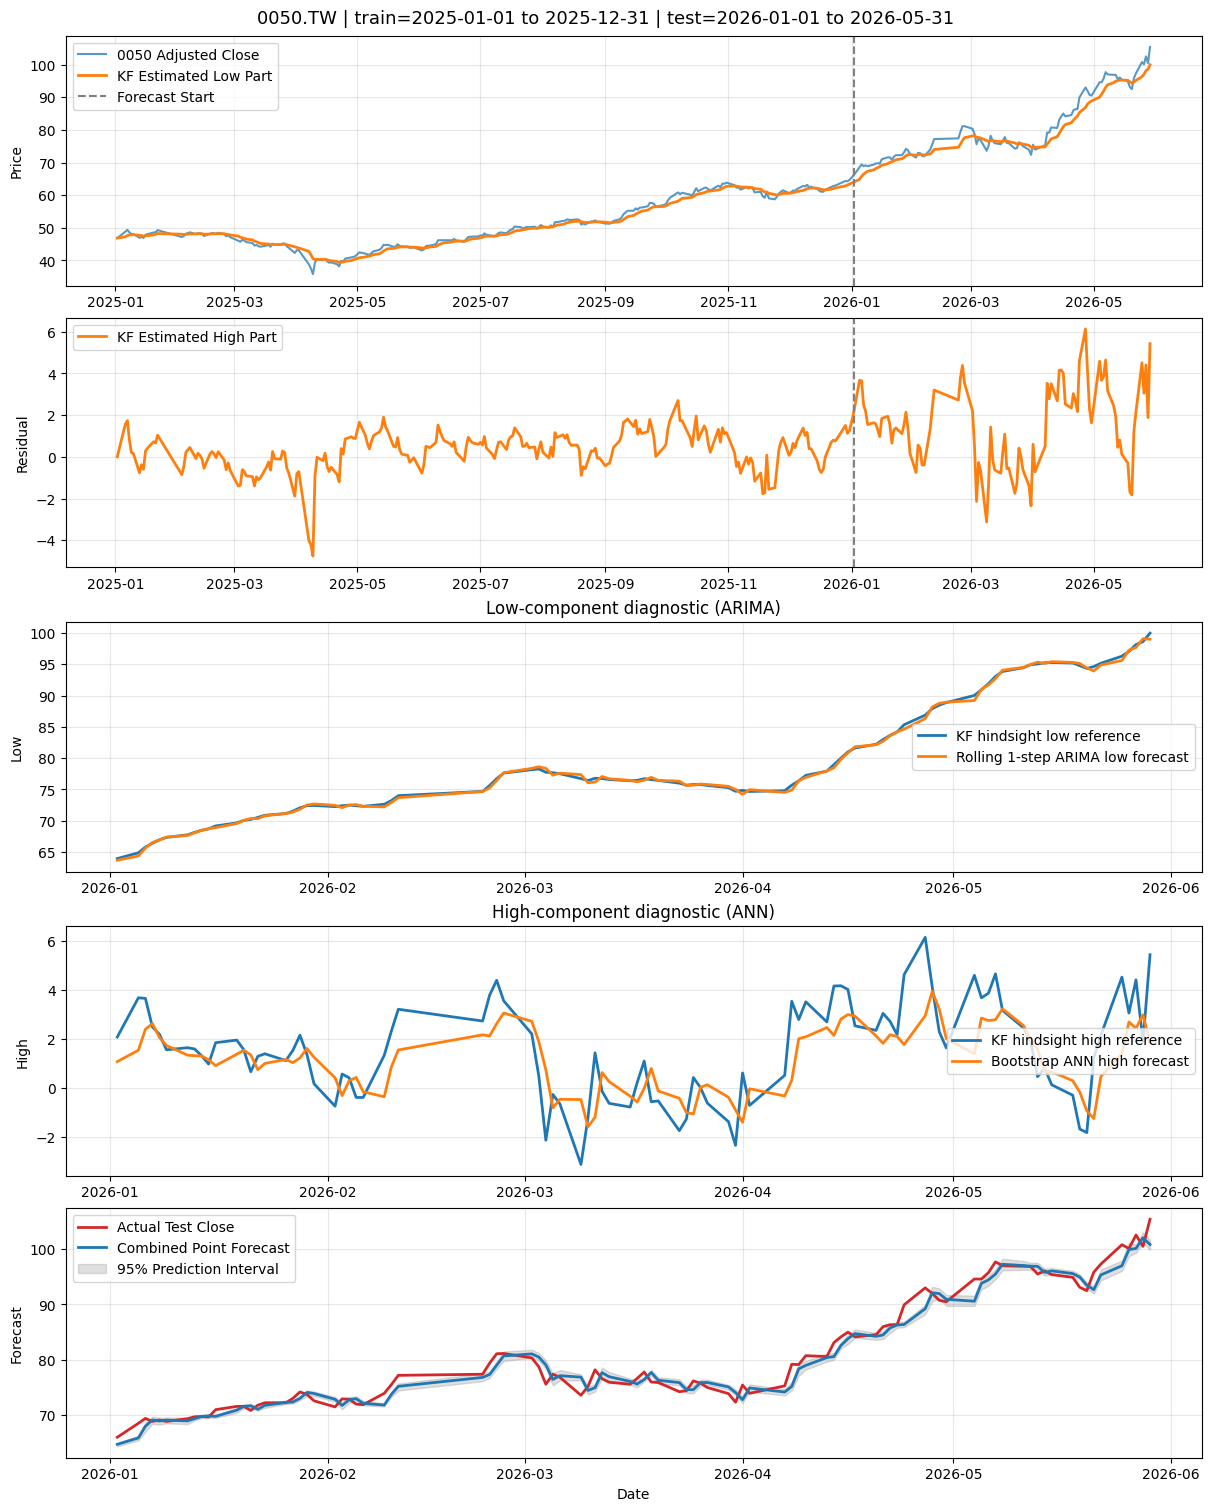

In [15]:
t = pd.to_datetime(result["full_dates"])
t_test = pd.to_datetime(result["test_dates"])
forecast_start = t_test[0]

fig, axes = plt.subplots(5, 1, figsize=(12, 15), constrained_layout=True)
fig.suptitle(
    f'{result["ticker"]} | train={result["train_period"]} | test={result["test_period"]}',
    fontsize=13,
)

axes[0].plot(t, result["measurements"], label="0050 Adjusted Close", alpha=0.75)
axes[0].plot(t, result["estimated_low_full"], label="KF Estimated Low Part", linewidth=2)
axes[0].axvline(forecast_start, color="gray", linestyle="--", label="Forecast Start")
axes[0].set_ylabel("Price")
axes[0].legend(loc="upper left")
axes[0].grid(True, alpha=0.3)

axes[1].plot(t, result["estimated_high_full"], label="KF Estimated High Part", linewidth=2, color="tab:orange")
axes[1].axvline(forecast_start, color="gray", linestyle="--")
axes[1].set_ylabel("Residual")
axes[1].legend(loc="upper left")
axes[1].grid(True, alpha=0.3)

axes[2].plot(t_test, result["reference_low_test"], label="KF hindsight low reference", linewidth=2)
axes[2].plot(t_test, result["low_forecast"], label="Rolling 1-step ARIMA low forecast", linewidth=2)
axes[2].set_title("Low-component diagnostic (ARIMA)")
axes[2].set_ylabel("Low")
axes[2].legend(loc="center right")
axes[2].grid(True, alpha=0.3)

axes[3].plot(t_test, result["reference_high_test"], label="KF hindsight high reference", linewidth=2)
axes[3].plot(t_test, result["high_forecast"], label="Bootstrap ANN high forecast", linewidth=2)
axes[3].set_title("High-component diagnostic (ANN)")
axes[3].set_ylabel("High")
axes[3].legend(loc="center right")
axes[3].grid(True, alpha=0.3)

axes[4].plot(t_test, result["measurements_test"], label="Actual Test Close", linewidth=2, color="tab:red")
axes[4].plot(t_test, result["final_forecast"], label="Combined Point Forecast", linewidth=2, color="tab:blue")
axes[4].fill_between(
    t_test,
    result["interval_lower"],
    result["interval_upper"],
    color="gray",
    alpha=0.25,
    label="95% Prediction Interval",
)
axes[4].set_ylabel("Forecast")
axes[4].set_xlabel("Date")
axes[4].legend(loc="upper left")
axes[4].grid(True, alpha=0.3)

plt.show()
plt.close(fig)



## Monte Carlo 摘要實驗

這一段會重複執行多次實驗，彙整 MSE、coverage、interval width，以及 component correlation 的平均表現。

In [ ]:
n_monte_carlo = 10
market_data = load_0050_actual_data()
bootstrap_replications = 100
horizon = len(market_data["test_series"])

print("Mode                          : 0050 actual data with fixed paper26-style setup")
print(f"Train period                  : {market_data['train_period']}")
print(f"Test period                   : {market_data['test_period']}")
print(f"Bootstrap replications        : {bootstrap_replications}")
print(f"Train points                  : {len(market_data['train_series'])}")
print(f"Test points (horizon)         : {horizon}")
print(f"Monte Carlo runs              : {n_monte_carlo}")
print("")
print("Mean low reference MSE | Mean high reference MSE | Mean actual test MSE | Mean actual test RMSE | Mean test std | Mean nRMSE | Mean actual test coverage | Mean interval width")
print("----------------------|-------------------------|----------------------|-----------------------|---------------|------------|--------------------------|--------------------")

start_time = time.perf_counter()
experiment_results = []

for run_idx in range(n_monte_carlo):
    np.random.seed(42 + run_idx)
    torch.manual_seed(42 + run_idx)
    experiment_results.append(
        run_single_experiment(
            ensemble_size=bootstrap_replications,
            market_data=market_data,
            validation_summary=None,
        )
    )

low_mses = np.array([result["low_mse"] for result in experiment_results], dtype=float)
high_mses = np.array([result["high_mse"] for result in experiment_results], dtype=float)
noisy_mses = np.array([result["final_noisy_mse"] for result in experiment_results], dtype=float)
noisy_rmses = np.array([result["final_noisy_rmse"] for result in experiment_results], dtype=float)
test_stds = np.array([result["test_std"] for result in experiment_results], dtype=float)
normalized_rmses = np.array([result["normalized_rmse"] for result in experiment_results], dtype=float)
noisy_coverages = np.array([result["noisy_coverage"] for result in experiment_results], dtype=float)
mean_interval_widths = np.array([result["mean_interval_width"] for result in experiment_results], dtype=float)
low_sample_widths = np.array([result["low_sample_width"] for result in experiment_results], dtype=float)
high_sample_widths = np.array([result["high_sample_width"] for result in experiment_results], dtype=float)
final_sample_widths = np.array([result["final_sample_width"] for result in experiment_results], dtype=float)
kf_component_corrs = np.array(
    [result["kf_component_corr"]["pearson_corr"] for result in experiment_results],
    dtype=float,
)
kf_component_corrsq = np.array(
    [result["kf_component_corr"]["corr_sq"] for result in experiment_results],
    dtype=float,
)
mean_data_generation = np.mean([result["timing_info"]["data_generation"] for result in experiment_results])
mean_point_forecast_fit = np.mean([result["timing_info"]["point_forecast_fit"] for result in experiment_results])
mean_kf_decomposition = np.mean([result["timing_info"]["kf_decomposition"] for result in experiment_results])
mean_arima_low_fit_forecast = np.mean([result["timing_info"]["arima_low_fit_forecast"] for result in experiment_results])
mean_ann_high_fit_forecast = np.mean([result["timing_info"]["ann_high_fit_forecast"] for result in experiment_results])

print(
    f"{np.mean(low_mses):.4f}                 | "
    f"{np.mean(high_mses):.4f}                  | "
    f"{np.mean(noisy_mses):.4f}               | "
    f"{np.mean(noisy_rmses):.4f}                | "
    f"{np.mean(test_stds):.4f}        | "
    f"{np.mean(normalized_rmses):.4f}     | "
    f"{np.mean(noisy_coverages):.2f}%                   | "
    f"{np.mean(mean_interval_widths):.4f}"
)
print(
    "Avg timing (s/run): "
    f"data={mean_data_generation:.2f}, "
    f"point_fit={mean_point_forecast_fit:.2f}"
)
print(
    "Avg model breakdown (s/run): "
    f"kf={mean_kf_decomposition:.2f}, "
    f"arima_low={mean_arima_low_fit_forecast:.2f}, "
    f"ann_high={mean_ann_high_fit_forecast:.2f}"
)
print(
    "Avg sample width: "
    f"low={np.mean(low_sample_widths):.4f}, "
    f"high={np.mean(high_sample_widths):.4f}, "
    f"final={np.mean(final_sample_widths):.4f}"
)
print(
    "Avg KF component corr: "
    f"{np.mean(kf_component_corrs):.4f} "
    f"(R^2={np.mean(kf_component_corrsq):.4f})"
)

representative = experiment_results[0]
t = pd.to_datetime(representative["full_dates"])
t_test = pd.to_datetime(representative["test_dates"])
forecast_start = t_test[0]

fig, axes = plt.subplots(4, 1, figsize=(12, 13), constrained_layout=True)
fig.suptitle(
    f'{representative["ticker"]} | Monte Carlo representative run\ntrain={representative["train_period"]} | test={representative["test_period"]}',
    fontsize=13,
)

axes[0].plot(t, representative["measurements"], label="0050 Adjusted Close", alpha=0.75)
axes[0].plot(t, representative["estimated_low_full"], label="KF Estimated Low Part", linewidth=2)
axes[0].axvline(forecast_start, color="gray", linestyle="--", label="Forecast Start")
axes[0].set_ylabel("Price")
axes[0].legend(loc="upper left")
axes[0].grid(True, alpha=0.3)

axes[1].plot(t, representative["estimated_high_full"], label="KF Estimated High Part", linewidth=2, color="tab:orange")
axes[1].axvline(forecast_start, color="gray", linestyle="--")
axes[1].set_ylabel("Residual")
axes[1].legend(loc="upper left")
axes[1].grid(True, alpha=0.3)

axes[2].plot(t_test, representative["reference_low_test"], label="KF hindsight low reference", linewidth=2)
axes[2].plot(t_test, representative["low_forecast"], label="Rolling 1-step ARIMA low forecast", linewidth=2)
axes[2].plot(t_test, representative["reference_high_test"], label="KF hindsight high reference", linewidth=2)
axes[2].plot(t_test, representative["high_forecast"], label="Bootstrap ANN high forecast", linewidth=2)
axes[2].set_title("KF-based component diagnostic (not observable ground truth)")
axes[2].set_ylabel("Components")
axes[2].legend(loc="center right")
axes[2].grid(True, alpha=0.3)

axes[3].plot(t_test, representative["measurements_test"], label="Actual Test Close", linewidth=2, color="tab:red")
axes[3].plot(t_test, representative["final_forecast"], label="Combined Point Forecast", linewidth=2, color="tab:blue")
axes[3].fill_between(
    t_test,
    representative["interval_lower"],
    representative["interval_upper"],
    color="gray",
    alpha=0.25,
    label="95% Prediction Interval",
)
axes[3].set_ylabel("Forecast")
axes[3].set_xlabel("Date")
axes[3].legend(loc="upper left")
axes[3].grid(True, alpha=0.3)

plt.show()
plt.close(fig)

elapsed_time = time.perf_counter() - start_time
print("")
print(f"Elapsed time                   : {elapsed_time:.2f} seconds")
